In [1]:
import seaborn as sns 
import pandas as pd
import numpy as np 

In [3]:
df = pd.read_csv('datas/Advertising.csv')

In [7]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [95]:
X = df.drop('Sales', axis=1)
X = X.drop('Unnamed: 0' , axis = 1)

y = df['Sales']

import matplotlib.pyplot as plt

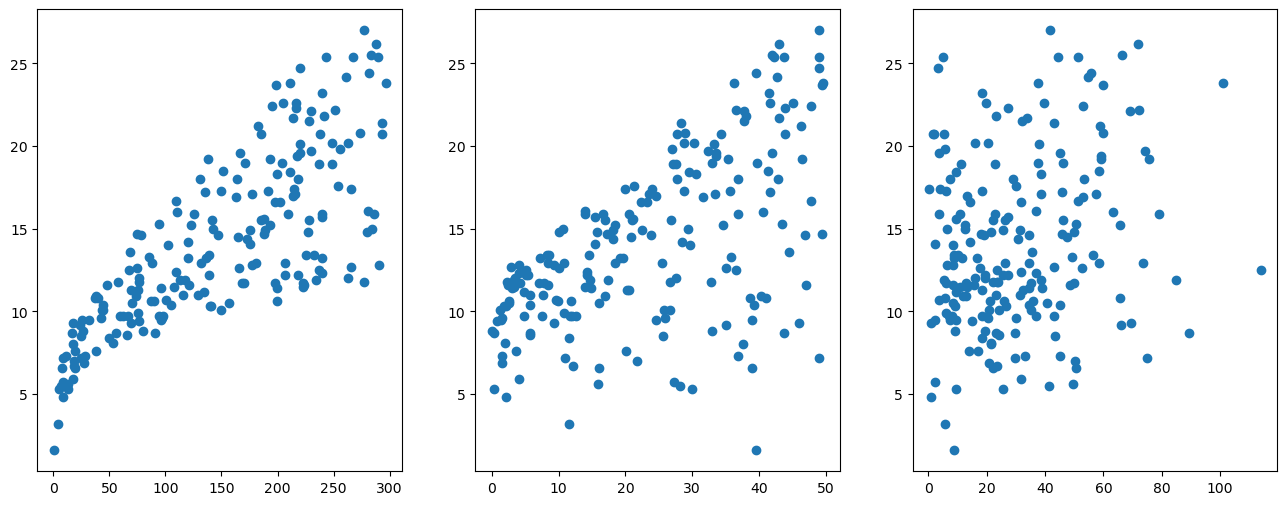

In [105]:
fig,axes = plt.subplots(nrows=1 , ncols=3 , figsize= (16,6))

axes[0].plot(df['TV'], df['Sales'] , 'o')
axes[1].plot(df['Radio'], df['Sales'] , 'o')
axes[2].plot(df['Newspaper'], df['Sales'] , 'o')

In [57]:
from sklearn.model_selection import train_test_split

In [59]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.3, random_state=101) 

In [61]:
from sklearn.linear_model import LinearRegression

In [71]:
model = LinearRegression()

model.fit(X_train , y_train)

y_prediction = model.predict(X_test)

In [73]:
model.coef_

array([ 0.04469599,  0.1875657 , -0.00032275])

In [75]:
model.intercept_ 

3.151526768070653

In [77]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score 

In [85]:
y.mean()

14.0225

In [109]:
mas = mean_absolute_error(y_test, y_prediction)

mse =mean_squared_error(y_test ,y_prediction)

r2 = r2_score(y_test, y_prediction)

In [87]:
# now we save our model and we will use it here again with new data 

In [117]:
final_model = LinearRegression()

final_model.fit(X , y )

LinearRegression()

In [119]:
y_hat = final_model.predict(X)

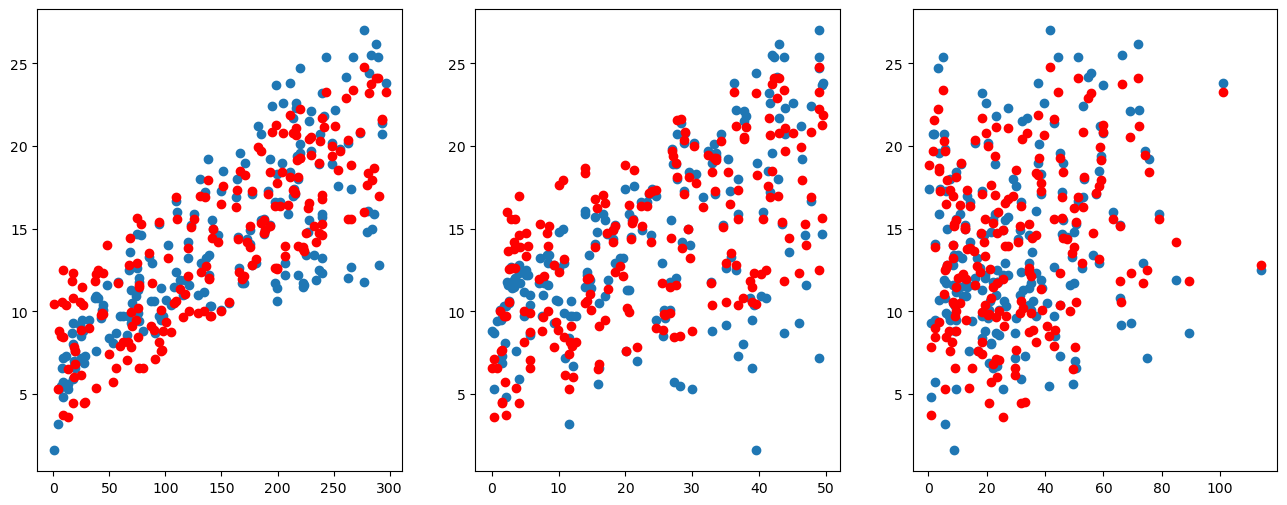

In [125]:
fig,axes = plt.subplots(nrows=1 , ncols=3 , figsize= (16,6))

axes[0].plot(df['TV'], df['Sales'] , 'o')
axes[0].plot(df['TV'], y_hat , 'o' , color='r')

axes[1].plot(df['Radio'], df['Sales'] , 'o')
axes[1].plot(df['Radio'], y_hat , 'o' , color='r')

axes[2].plot(df['Newspaper'], df['Sales'] , 'o')
axes[2].plot(df['Newspaper'], y_hat , 'o' , color='r')


In [127]:
final_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

In [129]:
final_model.intercept_

2.9388893694594067

In [133]:
df.drop('Unnamed: 0' , axis =1).corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


In [135]:
# now we use new data for out model and its real-time but latter (just moment )
# we save our model and load it again

In [137]:
from joblib import dump, load

In [139]:
dump(final_model, 'advertising_model.joblib')

['advertising_model.joblib']

In [141]:
load_model = load('advertising_model.joblib')

In [161]:
campain = [[200 , 0 , 0]]

In [163]:
load_model.predict(campain)

C:\Users\micro\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([12.09181846])